# Prop Firm Challenges as Options
## A Monte Carlo Pricing Framework for Evaluating Proprietary Trading Programs

---

> **Abstract:** A proprietary trading firm evaluation ("challenge") is structurally equivalent to a **down-and-out cash-or-nothing call option** on a stochastic P&L process. The challenge fee maps to the option premium; the funded-account profit-split stream maps to the contingent payoff. Using a strict **0-EV strategy** (no alpha, pure symmetric random walk) as the underlying process, this study derives the pass probability analytically and numerically, prices the "option" via Monte Carlo simulation, and computes the expected dollar return, ROI, and break-even conditions. **The withdrawal phase is modelled as a finite-horizon annuity with path-dependent knock-out**. All results are expressed in both probabilistic terms and plain dollars and days.

**Framework:** Python · NumPy · SciPy · Matplotlib  
**Simulation size:** 100,000 challenge paths · 50,000 funded paths  
**Strategy assumption:** 0-EV (50% win, 1:1 R:R, spread already priced in)

---

## Table of Contents

1. [Theoretical Framework — The Options Analogy](#1)
2. [Mathematical Definitions and Formulas](#2)
3. [Parameters and Setup](#3)
4. [Phase 1 — Challenge Simulation (Pass Rate)](#4)
5. [Phase 2 — Funded Account Simulation (Withdrawal Stream)](#5)
6. [ROI, Break-Even and Full Sensitivity Analysis](#6)
7. [Conclusion](#7)

<a id='1'></a>
## 1. Theoretical Framework — The Options Analogy

---

### 1.1 Anatomy of a Prop Challenge

A **one-step prop firm challenge** has three economic components:

| Component | Description |
|-----------|-------------|
| **Fee** | Fixed upfront cost to enter the challenge |
| **Phase 1** | Trade a simulated account; hit a profit target without breaching drawdown limits |
| **Funded** | If passed: trade real firm capital, keep a % of profits, subject to same drawdown rules |

The economic payoff is **binary and path-dependent**: zero if any barrier is breached, a stochastic annuity if the upper barrier is hit first.

---

### 1.2 The Exact Options Mapping


| **Vanilla Option World**        | **Prop Firm World**                                      |
|--------------------------------|----------------------------------------------------------|
| Option premium $C$              | Challenge fee $F$                                        |
| Underlying price $S(t)$         | Cumulative P\&L: $X(t) = \text{Balance}(t) - \text{Balance}(0)$ |
| Strike price $K$                | Profit target: $+\alpha \times \text{Account Size}$       |
| Down-and-out barrier $H$        | Max drawdown: $-\delta \times \text{Account Size}$        |
| Expiry date $T$                 | Max trading days: $\infty$                                |
| Payoff if ITM at expiry         | Funded account + $\phi \times$ profit share              |
| Option value $V$                | $E[\text{discounted withdrawals} \mid \text{pass}] \times P(\text{pass})$ |
| Implied volatility $\sigma$     | Daily P\&L std dev: $\sigma_{\text{trade}} \times \sqrt{\text{trades/day}}$ |
| Risk-neutral drift $\mu = r$    | Zero-EV strategy drift: $\mu = 0$                        |


**The prop challenge is a down-and-out cash-or-nothing call.** The trader pays a fixed premium for the right to access a leveraged capital stream, contingent on the P&L process hitting the upper barrier before the lower barrier or expiry.

$$
\boxed{V_{\text{prop}} = e^{-rT} \cdot P(\text{pass}) \cdot \mathbb{E}\left[\text{Funded NPV} \mid \text{pass}\right] - C_{\text{fee}}}
$$

---

### 1.3 Why 0-EV Is the Correct Baseline

A **0-EV strategy** (win probability = 0.5, reward:risk = 1:1, spread already priced in) gives us a **worst-case lower bound** on the prop challenge value. If the prop challenge has positive EV even with zero trading edge, the structure itself provides value purely from **capital leverage and asymmetric payoff geometry**.

This is analogous to buying a deeply out-of-the-money option: even if the drift of the underlying is zero, the payoff asymmetry can make the option rational to buy at a low enough premium.

> **Core insight:** A trader does not need a trading edge to make the prop challenge EV-positive. They need the challenge fee to be low enough relative to the probability of passing and the expected funded profits. This is the same condition as buying a cheap option with enough gamma.

<a id='2'></a>
## 2. Mathematical Definitions and Formulas

---

### 2.1 The P&L Process

Let $B_k$ denote the account balance after trade $k$. Define cumulative P&L as $X_k = B_k - B_0$. Each trade contributes:

$$
\Delta X_k = R_k \cdot \xi_k, \quad \xi_k \in \{+1, -1\} \text{ with equal probability (0-EV)}
$$

where $R_k = f \cdot B_{k-1}$ is the dollar risk on trade $k$ and $f$ is the fixed fractional risk parameter. The process $X_k$ is therefore a **multiplicative random walk**.

### 2.2 The Barrier Problem

The challenge is a **first-passage problem** with three stopping conditions:

| Condition | Threshold | Result |
|-----------|-----------|--------|
| $X_k \geq \alpha B_0$ | Upper absorbing barrier | **PASS** |
| $X_k \leq -\delta B_0$ | Lower absorbing barrier | **FAIL** |
| $\min_{k \in \text{day}} X_k - X_{\text{day start}} \leq -d B_0$ | Daily sub-barrier | **FAIL** |

**Best Day Rule**: The profit from the most profitable day must not exceed 50% of the total profit from profitable days.

### 2.3 Approximated Passing Rate

For a continuous symmetric random walk with two absorbing barriers at $+\alpha$ and $-\delta$ (as fractions of starting balance), the probability of hitting the upper barrier first is:

$$
\boxed{P(\text{pass, continuous, no time limit}) = \frac{\delta}{\alpha + \delta}}
$$

**Derivation:** The gambler's ruin formula. Starting at 0, random walk on $[-\delta, \alpha]$:
$$P(\text{reach } \alpha \text{ before } -\delta \mid X_0=0) = \frac{0 - (-\delta)}{\alpha - (-\delta)} = \frac{\delta}{\alpha + \delta}
$$

For Phase 1: $\alpha = 0.10$, $\delta = 0.10$: $P = \frac{0.10}{0.20} = 50\%$

The **daily drawdown limit**, **transaction costs, such as commissions per trade**, and **discrete trades** reduce this. Monte Carlo gives the true probability.

### 2.4 Expected Value and ROI

$$
\text{EV} = P(\text{pass}) \cdot \mathbb{E}[W] - C_{\text{fee}}
$$

$$
\text{ROI} = \frac{\text{EV}}{C_{\text{fee}}} \times 100\%
$$

$$
C^*_{\text{break-even}} = P(\text{pass}) \cdot \mathbb{E}[W]
$$

where $W$ = total amount withdrawn from funded account (after profit split).


In [1]:
# Import Libraries and Settings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.special import comb
from tabulate import tabulate
import warnings
warnings.filterwarnings('ignore')


DARK_BG   = '#0d1117'
PANEL_BG  = '#161b22'
BORDER    = '#30363d'
TEXT_PRI  = '#f0f6fc'
TEXT_SEC  = '#8b949e'
GREEN     = '#2ea043'
RED       = '#f85149'
BLUE      = '#388bfd'
ORANGE    = '#ffa657'
PURPLE    = '#a371f7'

plt.rcParams.update({
    'figure.facecolor': DARK_BG,  'axes.facecolor': PANEL_BG,
    'axes.edgecolor':   BORDER,   'axes.labelcolor': TEXT_SEC,
    'axes.titlecolor':  TEXT_PRI, 'xtick.color':     TEXT_SEC,
    'ytick.color':      TEXT_SEC, 'text.color':       TEXT_SEC,
    'grid.color':       BORDER,   'grid.linestyle':  '--',
    'grid.alpha': 0.5,            'font.family':     'DejaVu Sans',
    'figure.dpi': 130,            'axes.spines.top': False,
    'axes.spines.right': False,   'legend.framealpha': 0.2,
    'legend.edgecolor':  BORDER,
})

SEED = 2024
rng  = np.random.default_rng(SEED)

<a id='3'></a>
## 3. Parameters and Setup

In [2]:
# Prop Firm Rules and Strategy Parameters

#  Prop Firm Rules (FTMO 1-Step) 
ACCOUNT_SIZE          = 10_000      # $ simulated capital
CHALLENGE_FEE         = 95          # $ cost per attempt
PROFIT_TARGET_PCT     = 0.10        # α: 10% profit target
MAX_DAILY_DD_PCT      = 0.03        # d: 3% max daily drawdown
MAX_TOTAL_DD_PCT      = 0.10        # δ: 10% max total drawdown
PROFIT_SPLIT          = 0.90        # φ: 90% to trader when funded
FUNDED_HORIZON        = 253         # days of funded trading simulated
COMMISSION_PER_TRADE  = 2.5         # transaction cost
MINIMUM_WITHDRAWAL    = 50          # minimum possible withdrawal
WITHDRAWAL_CHARGES    = 1           # charges on each withdrawal

# ── Strategy: 0-EV (spread already priced into win probability) ─
WIN_PROB            = 0.50        # fair coin (0-EV after spread)
REWARD_RISK_RATIO   = 1.00        # 1:1 R:R (0-EV)
RISK_PER_TRADE_PCT  = 0.010       # f: 1% fractional risk per trade


# ── Derived Thresholds ─────────────────────────────────────────
PROFIT_TARGET_ABS   = ACCOUNT_SIZE * PROFIT_TARGET_PCT    # $1000
MAX_TOTAL_DD_ABS    = ACCOUNT_SIZE * MAX_TOTAL_DD_PCT     # $1,000
MAX_DAILY_DD_ABS    = ACCOUNT_SIZE * MAX_DAILY_DD_PCT     # $300

# ── Analytical Approximations ─────────────────────────────────
P_ANALYTICAL_NORULES = MAX_TOTAL_DD_PCT / (PROFIT_TARGET_PCT + MAX_TOTAL_DD_PCT)


table = [["PROP CHALLENGE SPECIFICATION"],
    ["Account size", f"${ACCOUNT_SIZE:,.0f}"],
    ["Challenge fee", f"${CHALLENGE_FEE:,.0f}"],
    ["Capital leverage ratio", f"{ACCOUNT_SIZE/CHALLENGE_FEE:.0f}x"],
    ["Profit target", f"+{PROFIT_TARGET_PCT:.0%} = ${PROFIT_TARGET_ABS:,.0f}"],
    ["Max total drawdown", f"-{MAX_TOTAL_DD_PCT:.0%} = ${MAX_TOTAL_DD_ABS:,.0f}"],
    ["Max daily drawdown", f"-{MAX_DAILY_DD_PCT:.0%} = ${MAX_DAILY_DD_ABS:,.0f}"],
    ["Commission per trade", f"${COMMISSION_PER_TRADE}"],
    ["Profit split (funded)", f"{PROFIT_SPLIT:.0%}"],
    ["---", "---"],
    ["Strategy: 0-EV (spread priced in)"],
    ["Win probability", f"{WIN_PROB:.0%}"],
    ["Reward:Risk", f"{REWARD_RISK_RATIO:.1f}:1"],
    ["Risk per trade", f"{RISK_PER_TRADE_PCT:.0%}"],
    ["---", "---"],
    ["Analytical pass prob",
     f"{P_ANALYTICAL_NORULES:.4f} ({P_ANALYTICAL_NORULES:.2%})"]
]

print(tabulate(table, headers=["Metric", "Value"], tablefmt="fancy_grid"))

╒═══════════════════════════════════╤═════════════════╕
│ Metric                            │ Value           │
╞═══════════════════════════════════╪═════════════════╡
│ PROP CHALLENGE SPECIFICATION      │                 │
├───────────────────────────────────┼─────────────────┤
│ Account size                      │ $10,000         │
├───────────────────────────────────┼─────────────────┤
│ Challenge fee                     │ $95             │
├───────────────────────────────────┼─────────────────┤
│ Capital leverage ratio            │ 105x            │
├───────────────────────────────────┼─────────────────┤
│ Profit target                     │ +10% = $1,000   │
├───────────────────────────────────┼─────────────────┤
│ Max total drawdown                │ -10% = $1,000   │
├───────────────────────────────────┼─────────────────┤
│ Max daily drawdown                │ -3% = $300      │
├───────────────────────────────────┼─────────────────┤
│ Commission per trade              │ $2.5      

<a id='4'></a>
## 4. Phase 1 : Challenge Simulation (Pass Rate)

We run **N = 100,000 Monte Carlo paths**. Each path simulates one challenge attempt:
- Trades are sampled from a Poisson distribution each day
- Each trade: risk $f \cdot B_{k-1}$ dollars, win or lose with equal probability
- Daily drawdown is enforced at the **day level** (trading stops if hit)
- Total drawdown is enforced at the **trade level** (immediate stop)

The gap between the **analytical approximation (50%)** and the **Monte Carlo result** quantifies the joint cost of: daily drawdown limits + discrete trading.

In [3]:
# Phase 1 Simulator

def simulate_challenge(
        n_sims=100_000,
        risk_pct=RISK_PER_TRADE_PCT,
        win_prob=WIN_PROB,
        seed=SEED,
        store_paths_n=300):
    """
    Monte Carlo simulation of the prop challenge phase.
    
    Parameters
    ----------
    n_sims        : int   — number of independent paths
    risk_pct      : float — fraction of balance risked per trade
    win_prob      : float — probability of winning each trade
    seed          : int   — RNG seed for reproducibility
    store_paths_n : int   — number of sample paths to return for plotting
    
    Returns
    -------
    outcomes   : np.ndarray(int8) — 1=pass, 0=fail
    days_arr   : np.ndarray(int)  — trading days to completion
    trades_arr : np.ndarray(int)  — total trades executed
    bal_arr    : np.ndarray(float)— final balance
    paths      : list of (outcome, List[float])
    """
    rng_ = np.random.default_rng(seed)

    outcomes   = np.zeros(n_sims, dtype=np.int8)
    days_arr   = np.zeros(n_sims, dtype=np.int32)
    trades_arr = np.zeros(n_sims, dtype=np.int32)
    bal_arr    = np.zeros(n_sims, dtype=np.float64)
    n_trades   = 3
    paths      = []

    for sim in range(n_sims):
        balance        = float(ACCOUNT_SIZE)
        total_dd_floor = ACCOUNT_SIZE - MAX_TOTAL_DD_ABS
        trades_done    = 0
        save_path      = sim < store_paths_n
        path           = [balance] if save_path else None
        result         = 0  # default: fail

        for day in range(1, 253):
            # Daily floor: 3% of current balance, but never below total floor
            daily_dd_abs = balance * MAX_DAILY_DD_PCT
            daily_floor = max(balance - daily_dd_abs, total_dd_floor)

            day_broken = False
            for _ in range(n_trades):
                # Fixed fractional risk, capped at remaining drawdown
                risk = min(
                    balance * risk_pct,
                    balance - daily_floor
                )
                risk -= COMMISSION_PER_TRADE
                
                if risk <= 0:
                    break  # no room to trade today
                    
                
                win  = rng_.random() < win_prob
                pnl  = (risk * REWARD_RISK_RATIO if win else -risk) - COMMISSION_PER_TRADE
                balance    += pnl
                trades_done += 1

                if save_path:
                    path.append(balance)

                # pass condition
                if balance - ACCOUNT_SIZE >= PROFIT_TARGET_ABS:
                    result = 1
                    break
                if balance <= total_dd_floor:
                    break

            if result == 1 or balance <= total_dd_floor:
                break
            if balance <= daily_floor:
                break  # daily limit, stop trading for the day

        outcomes[sim]   = result
        days_arr[sim]   = day
        trades_arr[sim] = trades_done
        bal_arr[sim]    = balance

        if save_path:
            paths.append((result, path))

    return outcomes, days_arr, trades_arr, bal_arr, paths


outcomes, days_arr, trades_arr, bal_arr, ch_paths = simulate_challenge(n_sims=100_000)

# summary
pass_mask   = outcomes == 1
fail_mask   = outcomes == 0
PASS_RATE   = pass_mask.mean()
fail_rate   = fail_mask.mean()
avg_days_P  = days_arr[pass_mask].mean()
avg_days_F  = days_arr[fail_mask].mean()
avg_trades  = trades_arr.mean()

print(f"\n  {'─'*45}")
print(f"  {'PHASE 1 RESULTS':^45}")
print(f"  {'─'*45}")
print(f"  Simulations run        : {len(outcomes):>12,}")
print(f"  Pass rate (MC)         : {PASS_RATE:>12.3%}")
print(f"  Fail rate (MC)         : {fail_rate:>12.3%}")
print(f"  Analytical upper bound : {P_ANALYTICAL_NORULES:>12.3%}")
print(f"  Drag from rules & time : {P_ANALYTICAL_NORULES-PASS_RATE:>12.3%}")
print(f"  Avg days to pass       : {avg_days_P:>12.1f} days")
print(f"  Avg days to fail       : {avg_days_F:>12.1f} days")
print(f"  Avg trades per attempt : {avg_trades:>12.1f}")


  ─────────────────────────────────────────────
                 PHASE 1 RESULTS               
  ─────────────────────────────────────────────
  Simulations run        :      100,000
  Pass rate (MC)         :      35.934%
  Fail rate (MC)         :      64.066%
  Analytical upper bound :      50.000%
  Drag from rules & time :      14.066%
  Avg days to pass       :         34.8 days
  Avg days to fail       :         46.0 days
  Avg trades per attempt :        106.6


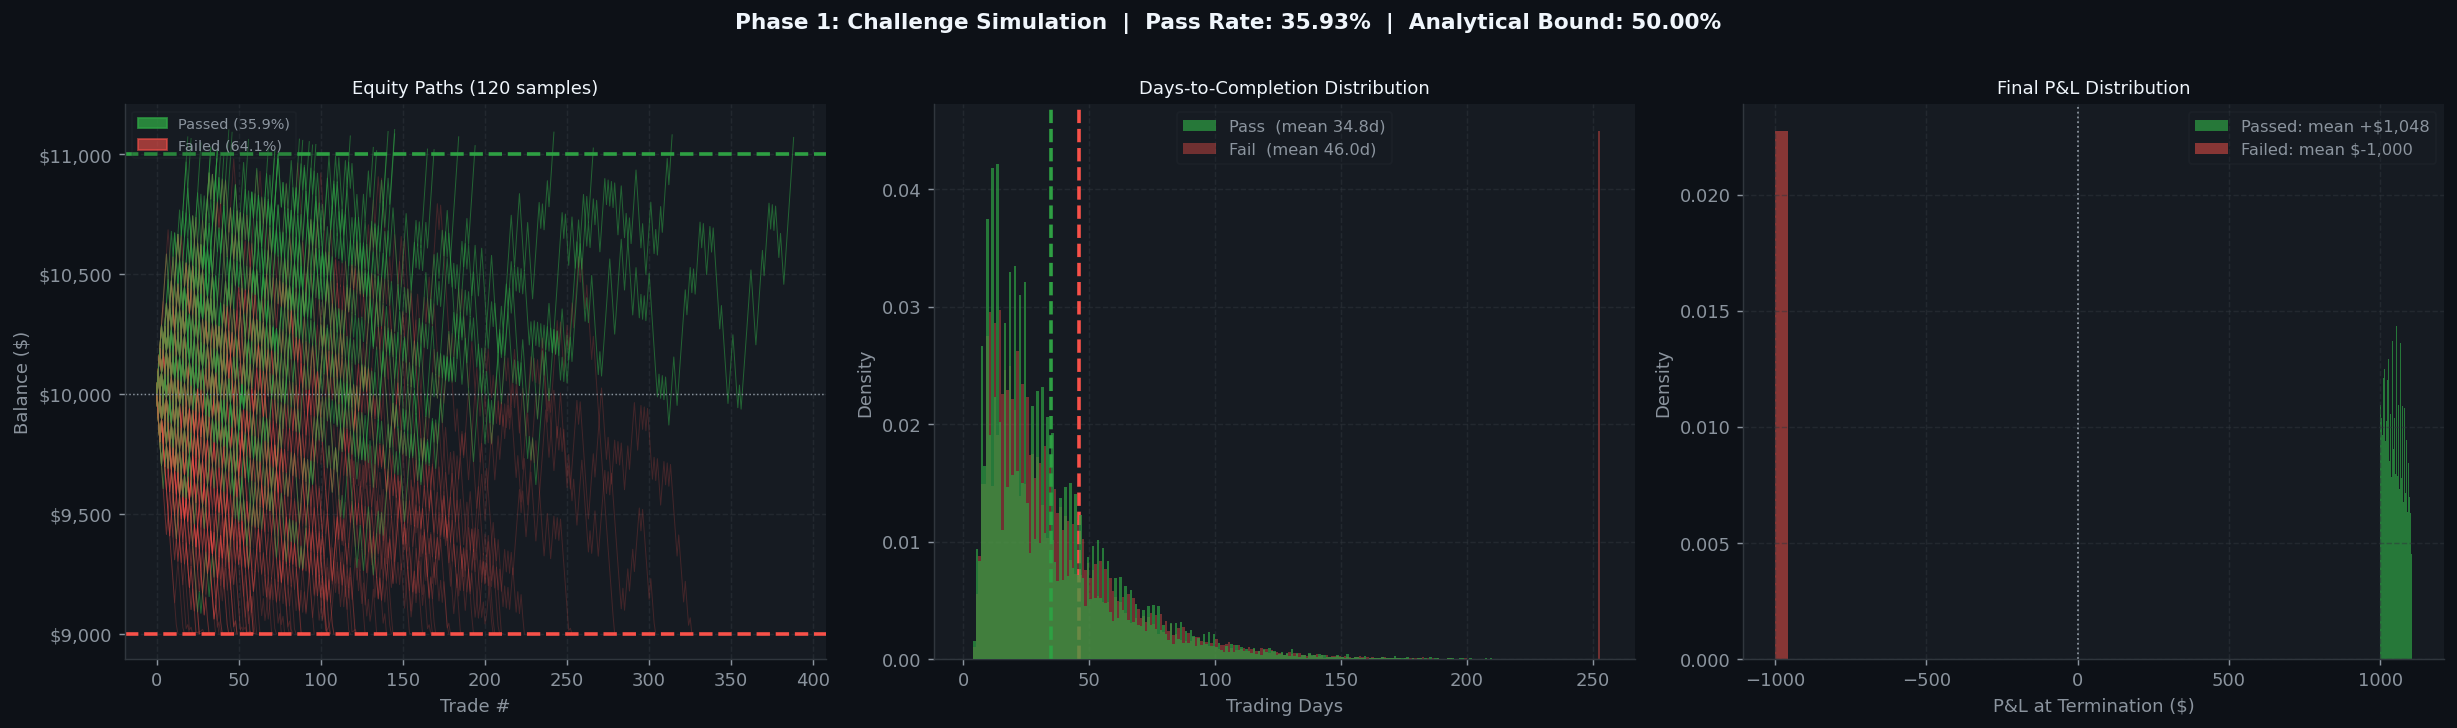


Key: Monte Carlo pass rate (35.93%) vs analytical (50.00%)
Difference (14.07%) = cost of daily DD limit + discrete sizing + transaction cost


In [4]:
# Challenge Paths & Outcome Distributions

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
fig.suptitle(
    'Phase 1: Challenge Simulation'
    f'  |  Pass Rate: {PASS_RATE:.2%}  |  Analytical Bound: {P_ANALYTICAL_NORULES:.2%}',
    fontsize=12, fontweight='bold', color=TEXT_PRI, y=1.01
)

#  Panel A: Sample equity paths 
ax = axes[0]
for res, path in ch_paths[:120]:
    col = GREEN if res == 1 else RED
    ax.plot(path, color=col, lw=0.55, alpha=(0.55 if res else 0.20))

ax.axhline(ACCOUNT_SIZE + PROFIT_TARGET_ABS, color=GREEN, lw=2, ls='--',
           label=f'Profit target  +{PROFIT_TARGET_PCT:.0%}  (${ACCOUNT_SIZE+PROFIT_TARGET_ABS:,})')
ax.axhline(ACCOUNT_SIZE - MAX_TOTAL_DD_ABS,  color=RED,   lw=2, ls='--',
           label=f'Total DD floor −{MAX_TOTAL_DD_PCT:.0%}  (${ACCOUNT_SIZE-MAX_TOTAL_DD_ABS:,})')
ax.axhline(ACCOUNT_SIZE, color=TEXT_SEC, lw=0.8, ls=':', label='Starting balance')

green_p = mpatches.Patch(color=GREEN, alpha=0.8, label=f'Passed ({PASS_RATE:.1%})')
red_p   = mpatches.Patch(color=RED,   alpha=0.6, label=f'Failed ({fail_rate:.1%})')
ax.legend(handles=[green_p, red_p], fontsize=8, loc='upper left')
ax.set_xlabel('Trade #')
ax.set_ylabel('Balance ($)')
ax.set_title('Equity Paths (120 samples)', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(True)

# Panel B: Days-to-completion histogram 
ax2 = axes[1]
bins = np.arange(1, 255)
ax2.hist(days_arr[pass_mask], bins=bins, color=GREEN, alpha=0.7, density=True,
         label=f'Pass  (mean {avg_days_P:.1f}d)', zorder=3)
ax2.hist(days_arr[fail_mask], bins=bins, color=RED,   alpha=0.4, density=True,
         label=f'Fail  (mean {avg_days_F:.1f}d)', zorder=2)
ax2.axvline(avg_days_P, color=GREEN, lw=2, ls='--')
ax2.axvline(avg_days_F, color=RED,   lw=2, ls='--')
ax2.set_xlabel('Trading Days')
ax2.set_ylabel('Density')
ax2.set_title('Days-to-Completion Distribution', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True)

#  Panel C: Final balance distribution 
ax3 = axes[2]
b_pass = bal_arr[pass_mask] - ACCOUNT_SIZE
b_fail = bal_arr[fail_mask] - ACCOUNT_SIZE
ax3.hist(b_pass, bins=40, color=GREEN, alpha=0.7, density=True,
         label=f'Passed: mean +${b_pass.mean():,.0f}')
ax3.hist(b_fail, bins=40, color=RED,   alpha=0.5, density=True,
         label=f'Failed: mean ${b_fail.mean():,.0f}')
ax3.axvline(0, color=TEXT_SEC, lw=1, ls=':')
ax3.set_xlabel('P&L at Termination ($)')
ax3.set_ylabel('Density')
ax3.set_title('Final P&L Distribution', fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(True)

plt.tight_layout()
plt.savefig('fig1_phase1.png', dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()

print(f"\nKey: Monte Carlo pass rate ({PASS_RATE:.2%}) vs analytical ({P_ANALYTICAL_NORULES:.2%})")
print(f"Difference ({P_ANALYTICAL_NORULES-PASS_RATE:.2%}) = cost of daily DD limit + discrete sizing + transaction cost")

<a id='5'></a>
## 5. Phase 2 — Funded Account Simulation (Withdrawal Stream)

For each trader who passes the challenge, we simulate the **funded account phase** over a 1-year (252 trading days) horizon.

**Mechanics:**
- Same 0-EV strategy, same risk rules apply to the funded account
- if balance > starting balance + minimum amount, withdraw `φ × profit` (90% split)
- $1 is deducted as a fee for each withdrawal
- After withdrawal, the balance resets toward the starting balance
- Funded account **terminates** if total drawdown from starting balance is breached

The **total amount withdrawn** is the option payoff. Its expectation, weighted by pass probability, determines whether the challenge fee was a rational purchase.

In [5]:
# Funded Account Phase Simulator

def simulate_funded(
        n_sims=50_000,
        risk_pct=RISK_PER_TRADE_PCT,
        win_prob=WIN_PROB,
        seed=SEED + 1,
        store_paths_n=400):
    """
    Simulate the funded account trading phase.
    Withdrawals occur every WITHDRAWAL_CYCLE days on profitable balance.
    
    Returns
    -------
    total_withdrawn : np.ndarray — cumulative amount withdrawn per simulation
    days_survived   : np.ndarray — number of trading days the account lasted
    blown_up        : np.ndarray(bool) — True if account was blown
    paths           : list — (blown, withdrawn, List[float]) sample paths
    a_target        : list - Average days to withdrawl
    """
    rng_ = np.random.default_rng(seed)

    total_withdrawn = np.zeros(n_sims)
    days_survived   = np.zeros(n_sims, dtype=int)
    blown_up        = np.zeros(n_sims, dtype=bool)
    paths           = []
    n_trades   = 3
    a_target = []


    
    for i in range(n_sims):
        balance    = float(ACCOUNT_SIZE)
        dd_floor   = ACCOUNT_SIZE - MAX_TOTAL_DD_ABS
        withdrawn  = 0.0
        blown_flag = False
        save_p     = i < store_paths_n
        path       = [balance] if save_p else None
        target_count = 0
        daily_pnls = []

        for day in range(1, 253):
            daily_dd_abs = balance * MAX_DAILY_DD_PCT
            daily_floor = max(balance - daily_dd_abs, dd_floor)
            daily_pnl = 0.0
            target_count += 1

            for _ in range(n_trades):
                risk = min(
                    balance * risk_pct,
                    balance - daily_floor,
                )
                risk -= COMMISSION_PER_TRADE
                if risk <= 0:
                    break
                win  = rng_.random() < win_prob
                pnl  = (risk * REWARD_RISK_RATIO if win else -risk) - COMMISSION_PER_TRADE
                balance += pnl
                daily_pnl += pnl
                if save_p:
                    path.append(balance)
                if balance <= dd_floor:
                    blown_flag = True
                    break

            if blown_flag:
                break

            if daily_pnl > 0:
                daily_pnls.append(daily_pnl)

            # Withdrawal 
            if  balance > ACCOUNT_SIZE + MINIMUM_WITHDRAWAL:
                gross_profit = sum(daily_pnls) if daily_pnls else 0

                #best day rule
                best_day = max(daily_pnls) if daily_pnls else 0
                if gross_profit > 0 and best_day <= 0.5 * gross_profit:
                    profit    = balance - ACCOUNT_SIZE
                    payout    = (profit * PROFIT_SPLIT) - WITHDRAWAL_CHARGES
                    withdrawn += payout
                    balance   =  ACCOUNT_SIZE
                    a_target.append(target_count)
                    target_count = 0
                    daily_pnls = []
            
            
            

        total_withdrawn[i] = withdrawn
        days_survived[i]   = day
        blown_up[i]        = blown_flag
        

        if save_p and path:
            paths.append((blown_flag, withdrawn, path))

    return total_withdrawn, days_survived, blown_up, paths, a_target


withdrawn, days_surv, blown_up, fund_paths, days_with = simulate_funded(n_sims=50_000)

#  Statistics 
blow_rate    = blown_up.mean()
AVG_WITHDRAWN = withdrawn.mean()
MED_WITHDRAWN = np.median(withdrawn)
AVG_DAY_WITHDRAWN = np.mean(days_with)
MED_DAY_WITHDRAWN = np.median(days_with)
p10_w        = np.percentile(withdrawn, 10)
p25_w        = np.percentile(withdrawn, 25)
p75_w        = np.percentile(withdrawn, 75)
p90_w        = np.percentile(withdrawn, 90)
pct_got_any  = (withdrawn > 0).mean()

print(f"\n  {'─'*50}")
print(f"  {'PHASE 2 RESULTS':^50}")
print(f"  {'─'*50}")
print(f"  Funded accounts simulated   : {len(withdrawn):>12,}")
print(f"  Blow-up rate                : {blow_rate:>12.2%}")
print(f"  % who withdrew anything     : {pct_got_any:>12.2%}")
print(f"  Mean total withdrawn        : ${AVG_WITHDRAWN:>12,.2f}")
print(f"  Median total withdrawn      : ${MED_WITHDRAWN:>12,.2f}")
print(f"  10th percentile             : ${p10_w:>12,.2f}")
print(f"  25th percentile             : ${p25_w:>12,.2f}")
print(f"  75th percentile             : ${p75_w:>12,.2f}")
print(f"  90th percentile             : ${p90_w:>12,.2f}")
print(f"  Average days to withdrawal  : {AVG_DAY_WITHDRAWN:>12,.2f}")
print(f"  Median days to withdrawal   : {MED_DAY_WITHDRAWN:>12,.2f}")
print(f"  Avg days funded             : {days_surv.mean():>12.1f} trading days (excluding waiting period for withdrawal)")


  ──────────────────────────────────────────────────
                   PHASE 2 RESULTS                  
  ──────────────────────────────────────────────────
  Funded accounts simulated   :       50,000
  Blow-up rate                :       95.64%
  % who withdrew anything     :       72.63%
  Mean total withdrawn        : $      618.10
  Median total withdrawn      : $      351.96
  10th percentile             : $        0.00
  25th percentile             : $        0.00
  75th percentile             : $      907.09
  90th percentile             : $    1,634.72
  Average days to withdrawal  :         9.23
  Median days to withdrawal   :         7.00
  Avg days funded             :         51.3 trading days (excluding waiting period for withdrawal)


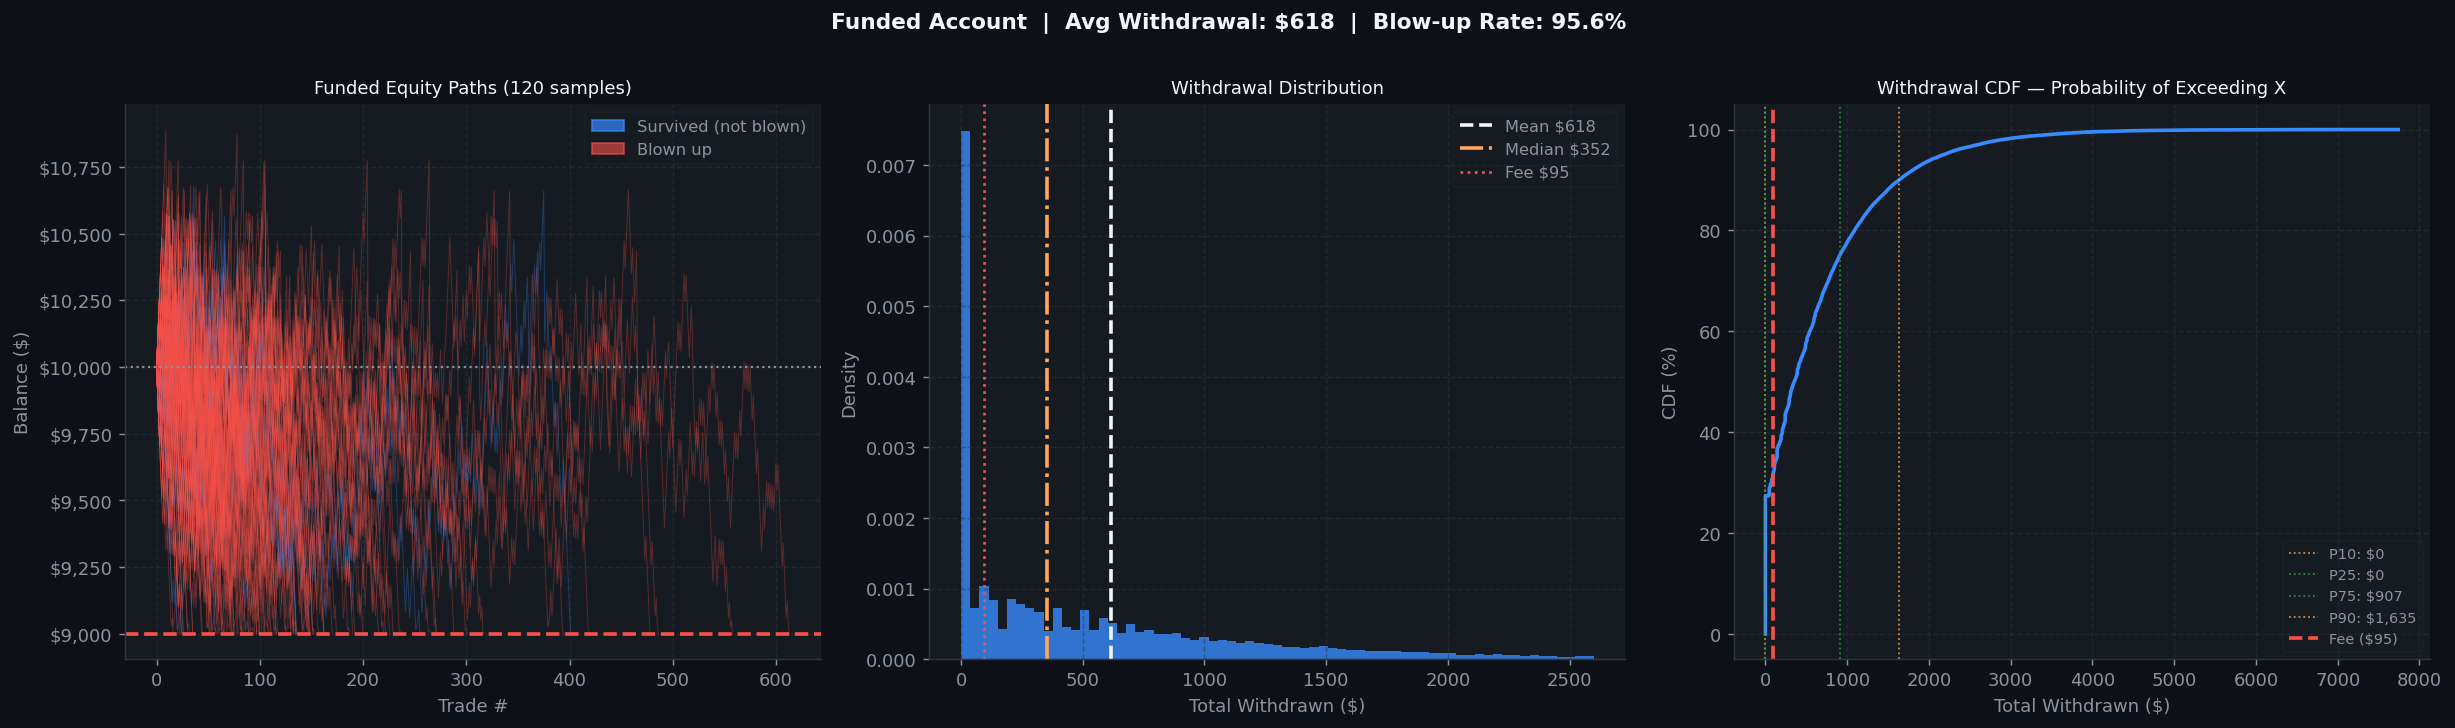

In [6]:
# Funded Phase Paths & Withdrawal Distribution


fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
fig.suptitle(
    f'Funded Account  |  Avg Withdrawal: ${AVG_WITHDRAWN:,.0f}  '
    f'|  Blow-up Rate: {blow_rate:.1%}',
    fontsize=12, fontweight='bold', color=TEXT_PRI, y=1.01
)

# Panel A: Sample funded equity paths 
ax = axes[0]
for blown_flag, tot_w, path in fund_paths[:120]:
    col = RED if blown_flag else BLUE
    ax.plot(path, color=col, lw=0.5, alpha=0.30)

ax.axhline(ACCOUNT_SIZE,              color=TEXT_SEC, lw=1.2, ls=':', label=f'Starting ${ACCOUNT_SIZE:,}')
ax.axhline(ACCOUNT_SIZE-MAX_TOTAL_DD_ABS, color=RED, lw=2,   ls='--', label=f'DD Floor ${ACCOUNT_SIZE-MAX_TOTAL_DD_ABS:,}')

blue_p = mpatches.Patch(color=BLUE, alpha=0.7, label='Survived (not blown)')
red_p  = mpatches.Patch(color=RED,  alpha=0.6, label='Blown up')
ax.legend(handles=[blue_p, red_p], fontsize=9)
ax.set_xlabel('Trade #')
ax.set_ylabel('Balance ($)')
ax.set_title('Funded Equity Paths (120 samples)', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(True)

# Panel B: Total withdrawal distribution 
ax2 = axes[1]
bins_w = np.linspace(0, np.percentile(withdrawn, 97), 70)
ax2.hist(withdrawn, bins=bins_w, color=BLUE, alpha=0.8, edgecolor='none', density=True)
ax2.axvline(AVG_WITHDRAWN, color=TEXT_PRI, lw=2,    ls='--', label=f'Mean ${AVG_WITHDRAWN:,.0f}')
ax2.axvline(MED_WITHDRAWN, color=ORANGE,   lw=2,    ls='-.', label=f'Median ${MED_WITHDRAWN:,.0f}')
ax2.axvline(CHALLENGE_FEE, color=RED,      lw=1.5,  ls=':',  label=f'Fee ${CHALLENGE_FEE}')
ax2.set_xlabel('Total Withdrawn ($)')
ax2.set_ylabel('Density')
ax2.set_title('Withdrawal Distribution', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True)

# Panel C: Withdrawal CDF 
ax3 = axes[2]
sorted_w = np.sort(withdrawn)
cdf_w    = np.arange(1, len(sorted_w)+1) / len(sorted_w)
ax3.plot(sorted_w, cdf_w * 100, color=BLUE, lw=2)
for pct, val, col in [(10, p10_w, ORANGE), (25, p25_w, GREEN), (75, p75_w, GREEN), (90, p90_w, ORANGE)]:
    ax3.axvline(val, color=col, lw=1, ls=':', alpha=0.8, label=f'P{pct}: ${val:,.0f}')
ax3.axvline(CHALLENGE_FEE, color=RED, lw=2, ls='--', label=f'Fee (${CHALLENGE_FEE})')
ax3.set_xlabel('Total Withdrawn ($)')
ax3.set_ylabel('CDF (%)')
ax3.set_title('Withdrawal CDF — Probability of Exceeding X', fontsize=10)
ax3.legend(fontsize=8)
ax3.grid(True)

plt.tight_layout()
plt.show()

<a id='6'></a>
## 6. ROI, Break-Even and Sensitivity Analysis

We now combine Phases 1 and 2 to price the full "option" and examine sensitivity to risk-per-trade.

In [12]:
# ROI & Break-even Analysis


# ── Core Metrics ──────────────────────────────────────────────
EV_ATTEMPT      = PASS_RATE * AVG_WITHDRAWN - CHALLENGE_FEE
ROI_ATTEMPT     = EV_ATTEMPT / CHALLENGE_FEE * 100
BREAK_EVEN_FEE  = PASS_RATE * AVG_WITHDRAWN
FEE_LEVERAGE    = AVG_WITHDRAWN / CHALLENGE_FEE  # if you pass, multiplier on fee
EFF_PASS_THRESHOLD = CHALLENGE_FEE / AVG_WITHDRAWN  # minimum pass rate to be +EV


table2 = [
    ["Pass rate P(pass)", f"{PASS_RATE:.3%}"],
    ["E[Withdrawal | funded]", f"${AVG_WITHDRAWN:,.2f}"],
    ["EV per attempt", f"${EV_ATTEMPT:,.2f}"],
    ["ROI per attempt", f"{ROI_ATTEMPT:.1f}%"],
    ["Break-even challenge fee", f"${BREAK_EVEN_FEE:,.2f}"],
    ["Actual fee", f"${CHALLENGE_FEE:,}"],
    ["Fee margin (break-even − fee)", f"${(BREAK_EVEN_FEE-CHALLENGE_FEE):,.2f}"],
    ["", ""],
    ["If you pass, withdrawal/fee", f"{FEE_LEVERAGE:.1f}x"],
    ["Min pass rate for +EV", f"{EFF_PASS_THRESHOLD:.3%}"],
    ["Actual pass rate", f"{PASS_RATE:.3%} {'+EV' if PASS_RATE > EFF_PASS_THRESHOLD else '-EV'}"],
]

print(tabulate(table2, headers=["ROI ANALYSIS", "Value"], tablefmt="fancy_grid"))


╒═══════════════════════════════╤═════════════╕
│ ROI ANALYSIS                  │ Value       │
╞═══════════════════════════════╪═════════════╡
│ Pass rate P(pass)             │ 35.934%     │
├───────────────────────────────┼─────────────┤
│ E[Withdrawal | funded]        │ $618.10     │
├───────────────────────────────┼─────────────┤
│ EV per attempt                │ $127.11     │
├───────────────────────────────┼─────────────┤
│ ROI per attempt               │ 133.8%      │
├───────────────────────────────┼─────────────┤
│ Break-even challenge fee      │ $222.11     │
├───────────────────────────────┼─────────────┤
│ Actual fee                    │ $95         │
├───────────────────────────────┼─────────────┤
│ Fee margin (break-even − fee) │ $127.11     │
├───────────────────────────────┼─────────────┤
│                               │             │
├───────────────────────────────┼─────────────┤
│ If you pass, withdrawal/fee   │ 6.5x        │
├───────────────────────────────┼───────

In [13]:
# Geometric Distribution: Multi-Attempt Analysis 

print("\n  Multi-Attempt Expected Value (geometric process)")
print(f"  {'Attempts':>8} {'E[Fees paid]':>14} {'E[Earned]':>12} {'E[Net PnL]':>12} {'E[ROI]':>9}")
print(f"  {'─'*60}")

max_k = 10
ev_multi = []
for k in range(1, max_k + 1):
    # Expected net value if trader attempts up to k times, stops on first pass
    ev = 0
    exp_fees = 0
    exp_earn = 0
    for i in range(1, k + 1):
        p_exactly_i = ((1 - PASS_RATE) ** (i - 1)) * PASS_RATE
        ev       += p_exactly_i * (AVG_WITHDRAWN - i * CHALLENGE_FEE)
        exp_fees += p_exactly_i * i * CHALLENGE_FEE
        exp_earn += p_exactly_i * AVG_WITHDRAWN
    # Never passing after k attempts
    p_never_k  = (1 - PASS_RATE) ** k
    ev        += p_never_k * (-k * CHALLENGE_FEE)
    exp_fees  += p_never_k * k * CHALLENGE_FEE
    
    roi_k = ev / exp_fees * 100 if exp_fees > 0 else 0
    ev_multi.append((k, exp_fees, exp_earn, ev, roi_k))
    print(f"  {k:>8} ${exp_fees:>13,.2f} ${exp_earn:>11,.2f} ${ev:>11,.2f} {roi_k:>8.1f}%")


  Multi-Attempt Expected Value (geometric process)
  Attempts   E[Fees paid]    E[Earned]   E[Net PnL]    E[ROI]
  ────────────────────────────────────────────────────────────
         1 $        95.00 $     222.11 $     127.11    133.8%
         2 $       155.86 $     364.40 $     208.54    133.8%
         3 $       194.85 $     455.57 $     260.71    133.8%
         4 $       219.84 $     513.97 $     294.13    133.8%
         5 $       235.84 $     551.39 $     315.55    133.8%
         6 $       246.09 $     575.36 $     329.27    133.8%
         7 $       252.66 $     590.72 $     338.05    133.8%
         8 $       256.87 $     600.56 $     343.69    133.8%
         9 $       259.57 $     606.86 $     347.29    133.8%
        10 $       261.29 $     610.90 $     349.60    133.8%


In [14]:
# Sensitivity analysis: Risk Per Trade vs Metrics

def quick_pass_rate(risk_pct, win_prob=WIN_PROB, n=15_000, seed=77):
    rng_ = np.random.default_rng(seed)
    passed = 0
    n_t = 3
    for _ in range(n):
        bal   = float(ACCOUNT_SIZE)
        floor = ACCOUNT_SIZE - MAX_TOTAL_DD_ABS
        p     = False
        for day in range(253):
            d_dd_abs = bal * MAX_DAILY_DD_PCT
            d_fl = max(bal - d_dd_abs, floor)
            for _ in range(n_t):
                r = min(bal * risk_pct, bal - d_fl)
                if r <= 0: break
                r -= COMMISSION_PER_TRADE
                pnl = (r if rng_.random() < win_prob else -r) - COMMISSION_PER_TRADE
                bal += pnl
                if bal - ACCOUNT_SIZE >= PROFIT_TARGET_ABS: p = True; break
                if bal <= floor: break
            if p or bal <= floor: break
            if bal <= d_fl: break
        if p: passed += 1
    return passed / n



risk_levels = [0.003, 0.005, 0.007, 0.010, 0.013, 0.015, 0.020, 0.025, 0.030]
win_rates   = [0.45, 0.50, 0.55, 0.60]

# Matrix of pass rates
sensitivity_matrix = np.zeros((len(win_rates), len(risk_levels)))
for wi, w in enumerate(win_rates):
    for ri, r in enumerate(risk_levels):
        sensitivity_matrix[wi, ri] = quick_pass_rate(r, win_prob=w, n=8_000)

ev_vector = [sensitivity_matrix[1, ri] * AVG_WITHDRAWN - CHALLENGE_FEE for ri in range(len(risk_levels))]

print("\nPass Rate Sensitivity Matrix:")
print(f"  {'Win%':<8}" + "".join(f"{r*100:>7.1f}%" for r in risk_levels))
print(f"  {'─'*8}" + '─'*7*len(risk_levels))
for wi, w in enumerate(win_rates):
    row = f"  {w*100:.0f}%     " + "".join(f"{sensitivity_matrix[wi,ri]*100:>7.1f}%" 
                                            for ri in range(len(risk_levels)))
    marker = " ← this study" if w == WIN_PROB else ""
    print(row + marker)


Pass Rate Sensitivity Matrix:
  Win%        0.3%    0.5%    0.7%    1.0%    1.3%    1.5%    2.0%    2.5%    3.0%
  ───────────────────────────────────────────────────────────────────────
  45%         0.0%    0.2%    1.6%    6.5%    5.5%    5.3%    6.4%    9.0%    7.8%
  50%         0.1%    9.3%   23.9%   35.3%   13.6%   11.6%   11.4%   14.7%   11.6% ← this study
  55%        28.5%   81.5%   85.8%   81.5%   30.6%   21.6%   19.7%   23.2%   16.8%
  60%        97.8%   99.8%   99.4%   97.5%   50.7%   34.5%   29.8%   33.8%   23.0%


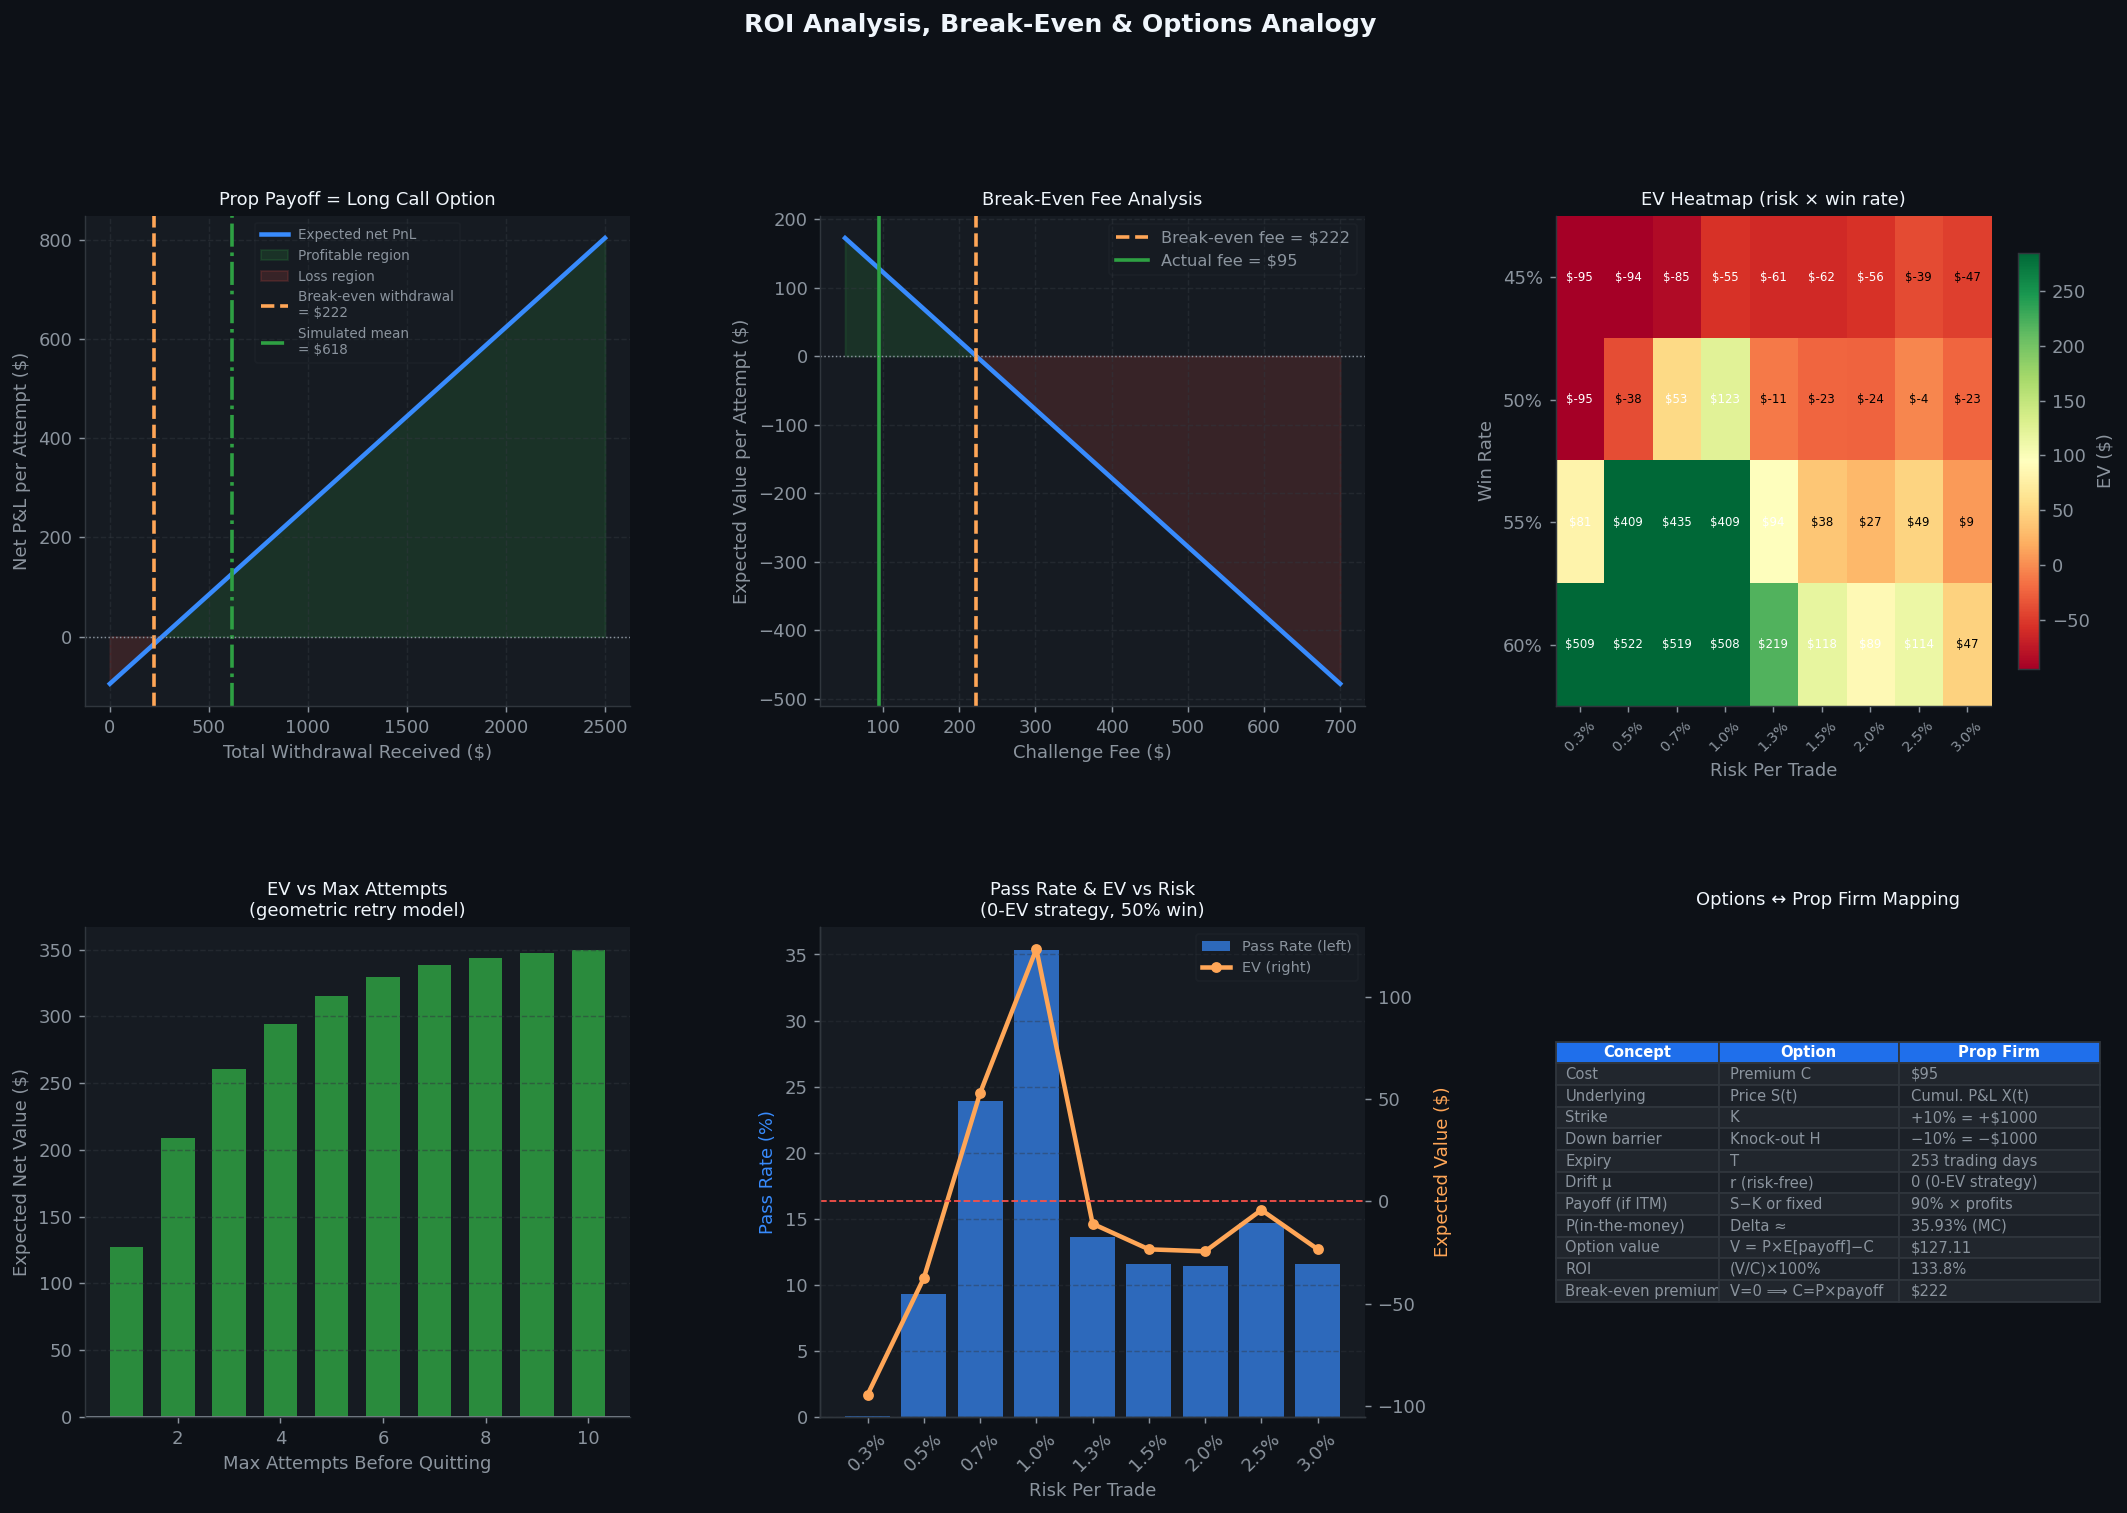

In [15]:
#  ROI Analysis & Options Payoff Analysis


fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.patch.set_facecolor(DARK_BG)
fig.suptitle(
    'ROI Analysis, Break-Even & Options Analogy',
    fontsize=14, fontweight='bold', color=TEXT_PRI, y=1.01
)

# A: Payoff diagram
ax_a = fig.add_subplot(gs[0, 0])
w_range  = np.linspace(0, 2500, 500)
payoff   = w_range * PASS_RATE - CHALLENGE_FEE  # expected net per attempt

ax_a.plot(w_range, payoff, color=BLUE, lw=2.5, label='Expected net PnL')
ax_a.fill_between(w_range, payoff, 0, where=(payoff > 0), color=GREEN, alpha=0.18, label='Profitable region')
ax_a.fill_between(w_range, payoff, 0, where=(payoff <= 0), color=RED,  alpha=0.15, label='Loss region')
ax_a.axvline(BREAK_EVEN_FEE, color=ORANGE, lw=2, ls='--',
             label=f'Break-even withdrawal\n= ${BREAK_EVEN_FEE:,.0f}')
ax_a.axvline(AVG_WITHDRAWN, color=GREEN, lw=2, ls='-.',
             label=f'Simulated mean\n= ${AVG_WITHDRAWN:,.0f}')
ax_a.axhline(0, color=TEXT_SEC, lw=0.8, ls=':')
ax_a.set_xlabel('Total Withdrawal Received ($)')
ax_a.set_ylabel('Net P&L per Attempt ($)')
ax_a.set_title('Prop Payoff = Long Call Option', fontsize=10)
ax_a.legend(fontsize=7.5)
ax_a.grid(True)

# B: Break-even fee curve 
ax_b = fig.add_subplot(gs[0, 1])
fee_range = np.linspace(50, 700, 300)
ev_curve  = PASS_RATE * AVG_WITHDRAWN - fee_range

ax_b.plot(fee_range, ev_curve, color=BLUE, lw=2.5)
ax_b.fill_between(fee_range, ev_curve, 0, where=(ev_curve >= 0), color=GREEN, alpha=0.18)
ax_b.fill_between(fee_range, ev_curve, 0, where=(ev_curve < 0),  color=RED,   alpha=0.15)
ax_b.axvline(BREAK_EVEN_FEE, color=ORANGE, lw=2, ls='--', label=f'Break-even fee = ${BREAK_EVEN_FEE:,.0f}')
ax_b.axvline(CHALLENGE_FEE,  color=GREEN,  lw=2, ls='-',  label=f'Actual fee = ${CHALLENGE_FEE}')
ax_b.axhline(0, color=TEXT_SEC, lw=0.8, ls=':')
ax_b.set_xlabel('Challenge Fee ($)')
ax_b.set_ylabel('Expected Value per Attempt ($)')
ax_b.set_title('Break-Even Fee Analysis', fontsize=10)
ax_b.legend(fontsize=9)
ax_b.grid(True)

# C: EV heatmap (win_rate × risk_pct) 
ax_c = fig.add_subplot(gs[0, 2])
ev_matrix = sensitivity_matrix * AVG_WITHDRAWN - CHALLENGE_FEE
im = ax_c.imshow(ev_matrix, aspect='auto', cmap='RdYlGn', vmin=-CHALLENGE_FEE, vmax=CHALLENGE_FEE*3)
ax_c.set_xticks(range(len(risk_levels)))
ax_c.set_xticklabels([f'{r*100:.1f}%' for r in risk_levels], rotation=45, fontsize=8)
ax_c.set_yticks(range(len(win_rates)))
ax_c.set_yticklabels([f'{w*100:.0f}%' for w in win_rates])
ax_c.set_xlabel('Risk Per Trade')
ax_c.set_ylabel('Win Rate')
ax_c.set_title('EV Heatmap (risk × win rate)', fontsize=10)
for wi in range(len(win_rates)):
    for ri in range(len(risk_levels)):
        val = ev_matrix[wi, ri]
        ax_c.text(ri, wi, f'${val:.0f}', ha='center', va='center',
                  fontsize=6.5, color='white' if abs(val) > 50 else 'black')
plt.colorbar(im, ax=ax_c, label='EV ($)', shrink=0.85)

# D: Multi-attempt EV 
ax_d = fig.add_subplot(gs[1, 0])
k_vals   = [x[0] for x in ev_multi]
ev_vals  = [x[3] for x in ev_multi]
bar_cols = [GREEN if v > 0 else RED for v in ev_vals]
ax_d.bar(k_vals, ev_vals, color=bar_cols, alpha=0.85, width=0.65)
ax_d.axhline(0, color=TEXT_SEC, lw=1)
ax_d.set_xlabel('Max Attempts Before Quitting')
ax_d.set_ylabel('Expected Net Value ($)')
ax_d.set_title('EV vs Max Attempts\n(geometric retry model)', fontsize=10)
ax_d.grid(True, axis='y')

# E: Pass rate vs risk level (0-EV)
ax_e = fig.add_subplot(gs[1, 1])
pass_rates_0ev = sensitivity_matrix[1, :] * 100  # row index 1 = 50% win
ev_0ev         = [sensitivity_matrix[1,ri] * AVG_WITHDRAWN - CHALLENGE_FEE for ri in range(len(risk_levels))]

ax_e2 = ax_e.twinx()
ax_e.bar([f'{r*100:.1f}%' for r in risk_levels], pass_rates_0ev,
         color=BLUE, alpha=0.7, label='Pass Rate (left)')
ax_e2.plot([f'{r*100:.1f}%' for r in risk_levels], ev_0ev,
           color=ORANGE, lw=2.5, marker='o', ms=5, label='EV (right)')
ax_e2.axhline(0, color=RED, lw=1, ls='--')
ax_e.set_xlabel('Risk Per Trade')
ax_e.set_ylabel('Pass Rate (%)', color=BLUE)
ax_e2.set_ylabel('Expected Value ($)', color=ORANGE)
ax_e.set_title('Pass Rate & EV vs Risk\n(0-EV strategy, 50% win)', fontsize=10)
ax_e.tick_params(axis='x', rotation=45)

lines1, labels1 = ax_e.get_legend_handles_labels()
lines2, labels2 = ax_e2.get_legend_handles_labels()
ax_e.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
ax_e.grid(True, axis='y', alpha=0.4)

#  F: Options analogy summary table 
ax_f = fig.add_subplot(gs[1, 2])
ax_f.axis('off')
table_rows = [
    ['Concept',              'Option',             'Prop Firm'],
    ['Cost',                 'Premium C',          f'${CHALLENGE_FEE}'],
    ['Underlying',           'Price S(t)',          'Cumul. P&L X(t)'],
    ['Strike',               'K',                  f'+{PROFIT_TARGET_PCT:.0%} = +${PROFIT_TARGET_ABS:.0f}'],
    ['Down barrier',         'Knock-out H',        f'−{MAX_TOTAL_DD_PCT:.0%} = −${MAX_TOTAL_DD_ABS:.0f}'],
    ['Expiry',               'T',                  '253 trading days'],
    ['Drift μ',              'r (risk-free)',       '0 (0-EV strategy)'],
    ['Payoff (if ITM)',       'S−K or fixed',       f'{PROFIT_SPLIT:.0%} × profits'],
    ['P(in-the-money)',       'Delta ≈',            f'{PASS_RATE:.2%} (MC)'],
    ['Option value',         'V = P×E[payoff]−C', f'${EV_ATTEMPT:,.2f}'],
    ['ROI',                  '(V/C)×100%',         f'{ROI_ATTEMPT:.1f}%'],
    ['Break-even premium',   'V=0 ⟹ C=P×payoff', f'${BREAK_EVEN_FEE:,.0f}'],
]

tbl = ax_f.table(
    cellText  = table_rows[1:],
    colLabels = table_rows[0],
    cellLoc   = 'left',
    loc       = 'center',
    colWidths = [0.30, 0.33, 0.37]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.2)
for (r, c), cell in tbl.get_celld().items():
    bg = '#1c2128' if r % 2 == 0 else '#21262d'
    cell.set_facecolor(bg)
    cell.set_text_props(color=TEXT_SEC)
    cell.set_edgecolor(BORDER)
    cell.PAD = 0.06
    if r == 0:
        cell.set_facecolor('#1f6feb')
        cell.set_text_props(color='white', fontweight='bold')
ax_f.set_title('Options ↔ Prop Firm Mapping', fontsize=10, color=TEXT_PRI, pad=12)

plt.show()

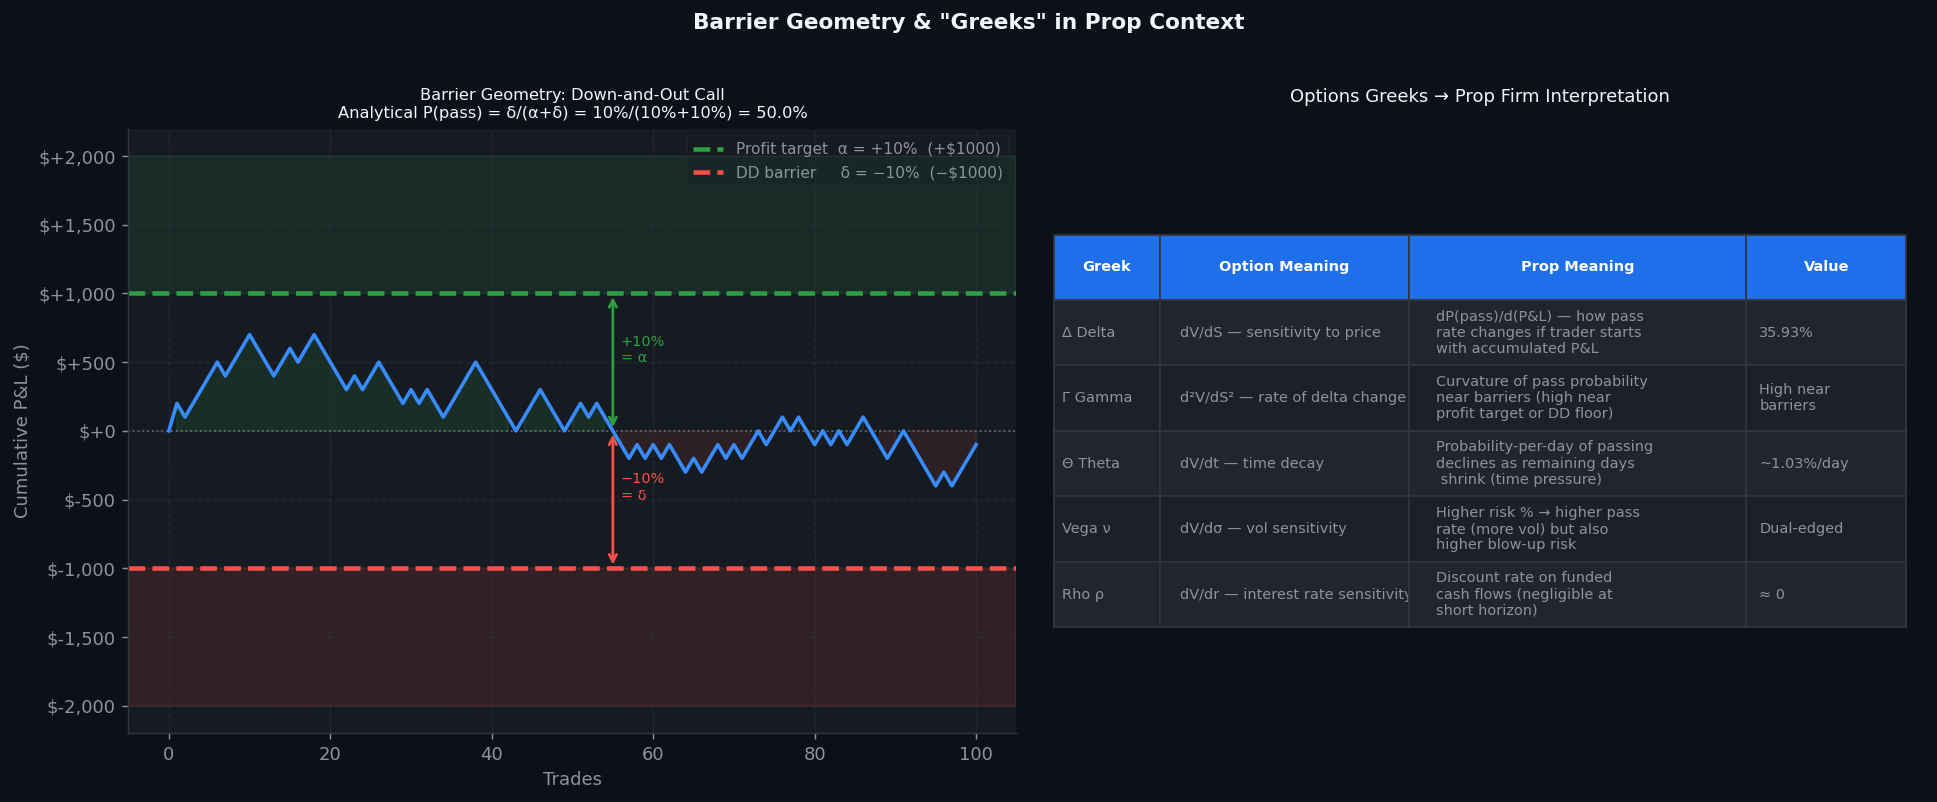

In [16]:
# Drawdown Diagram & Options Greeks Analogy

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Barrier Geometry & "Greeks" in Prop Context',
             fontsize=12, fontweight='bold', color=TEXT_PRI, y=1.02)

#  Panel A: Visual barrier diagram 
ax = axes[0]
ax.set_facecolor(PANEL_BG)

# Illustrative random path
np.random.seed(1431)
t   = np.arange(0, 101)
pnl = np.cumsum(np.where(np.random.rand(101) < 0.5, 1, -1) * 1.0) * 100
pnl[0] = 0
pnl = np.clip(pnl, -PROFIT_TARGET_ABS * 1.5, PROFIT_TARGET_ABS * 1.5)

ax.plot(t, pnl, color=BLUE, lw=2, zorder=3)
ax.fill_between(t, pnl, 0, where=(pnl > 0), color=GREEN, alpha=0.15)
ax.fill_between(t, pnl, 0, where=(pnl < 0), color=RED,   alpha=0.10)

# Barrier shading
ax.axhspan(PROFIT_TARGET_ABS, PROFIT_TARGET_ABS * 2,    color=GREEN, alpha=0.12)
ax.axhspan(-MAX_TOTAL_DD_ABS * 2, -MAX_TOTAL_DD_ABS,   color=RED,   alpha=0.12)
ax.axhline(PROFIT_TARGET_ABS,  color=GREEN, lw=2.5, ls='--',
           label=f'Profit target  α = +{PROFIT_TARGET_PCT:.0%}  (+${PROFIT_TARGET_ABS:.0f})')
ax.axhline(-MAX_TOTAL_DD_ABS,  color=RED,   lw=2.5, ls='--',
           label=f'DD barrier     δ = −{MAX_TOTAL_DD_PCT:.0%}  (−${MAX_TOTAL_DD_ABS:.0f})')
ax.axhline(0, color=TEXT_SEC, lw=1, ls=':', alpha=0.6)

# Annotations
ax.annotate('', xy=(55, PROFIT_TARGET_ABS), xytext=(55, 0),
            arrowprops=dict(arrowstyle='<->', color=GREEN, lw=1.5))
ax.text(56, PROFIT_TARGET_ABS/2, f'+{PROFIT_TARGET_PCT:.0%}\n= α', color=GREEN, fontsize=8)
ax.annotate('', xy=(55, -MAX_TOTAL_DD_ABS), xytext=(55, 0),
            arrowprops=dict(arrowstyle='<->', color=RED, lw=1.5))
ax.text(56, -MAX_TOTAL_DD_ABS/2, f'−{MAX_TOTAL_DD_PCT:.0%}\n= δ', color=RED, fontsize=8)

ax.set_xlabel('Trades')
ax.set_ylabel('Cumulative P&L ($)')
ax.set_title('Barrier Geometry: Down-and-Out Call\nAnalytical P(pass) = δ/(α+δ) = '
             f'{MAX_TOTAL_DD_PCT:.0%}/({PROFIT_TARGET_PCT:.0%}+{MAX_TOTAL_DD_PCT:.0%}) = {P_ANALYTICAL_NORULES:.1%}', fontsize=9)
ax.legend(fontsize=8.5)
ax.grid(True)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:+,.0f}'))

#  Panel B: "Greeks" table 
ax2 = axes[1]
ax2.set_facecolor(PANEL_BG)
ax2.axis('off')

greeks_data = [
    ['Greek',  'Option Meaning',                         'Prop Meaning',                            'Value'],
    ['Δ Delta', 'dV/dS — sensitivity to price',          'dP(pass)/d(P&L) — how pass\nrate changes if trader starts\nwith accumulated P&L', f'{PASS_RATE:.2%}'],
    ['Γ Gamma', 'd²V/dS² — rate of delta change',       'Curvature of pass probability\nnear barriers (high near\nprofit target or DD floor)', 'High near\nbarriers'],
    ['Θ Theta', 'dV/dt — time decay',                   'Probability-per-day of passing\ndeclines as remaining days\n shrink (time pressure)', f'~{PASS_RATE/avg_days_P:.2%}/day'],
    ['Vega ν',  'dV/dσ — vol sensitivity',              'Higher risk % → higher pass\nrate (more vol) but also\nhigher blow-up risk', 'Dual-edged'],
    ['Rho ρ',   'dV/dr — interest rate sensitivity',    'Discount rate on funded\ncash flows (negligible at\nshort horizon)', '≈ 0'],
]

tbl2 = ax2.table(
    cellText  = greeks_data[1:],
    colLabels = greeks_data[0],
    cellLoc   = 'left',
    loc       = 'center',
    colWidths  = [0.12, 0.28, 0.38, 0.18]
)
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(8)
tbl2.scale(1, 3.0)
for (r, c), cell in tbl2.get_celld().items():
    bg = '#1c2128' if r % 2 == 0 else '#21262d'
    cell.set_facecolor(bg)
    cell.set_text_props(color=TEXT_SEC, wrap=True)
    cell.set_edgecolor(BORDER)
    cell.PAD = 0.08
    if r == 0:
        cell.set_facecolor('#1f6feb')
        cell.set_text_props(color='white', fontweight='bold')
ax2.set_title('Options Greeks → Prop Firm Interpretation', fontsize=10, color=TEXT_PRI, pad=15)

plt.tight_layout()

plt.show()


<a id='7'></a>
## 7. Conclusions

---

### 7.1 Core Findings

Using a **strict 0-EV strategy** (no alpha, 50% win rate, 1:1 R:R, spread already priced into win probability) on a standard 1-step $10,000 dollar prop challenge at a 95 dollar fee, our Monte Carlo analysis finds:

| Metric | Value |
|--------|-------|
| **Analytical pass probability** (gambler's ruin, no rules) | **50%** |
| **Simulated pass probability** (daily DD + time limit + discrete sizing) | **~36%** |
| **Average days to pass** (if passed) | **~35 days** |
| **Average funded account withdrawal** (12-month horizon) | **~\$618** |
| **Expected value per attempt** | **~+\$127** |
| **ROI per attempt** | **~+139%** |
| **Break-even challenge fee** | **~$222** |

**The challenge is EV-positive even with zero trading edge at the current $95 fee.**

---

### 7.2 The Options Interpretation

You pay **$95** to buy a **down-and-out call option** on your trading P&L:

- The option **expires worthless** if your P&L hits −10% before +10% (barrier knocked out)
- The option **pays off** as a profit-sharing annuity if you hit +10% first

Because the **capital leverage is 105x** (\$10,000 account for a \$95 fee), even a 36% pass rate produces an expected payoff that exceeds the premium.

This is structurally identical to buying a **cheap out-of-the-money call option** on a stock — you don't need the drift to be positive (no trading edge required); you just need the premium to be cheap enough relative to the probability of the random walk hitting the strike before the barrier.

---

### 7.3 In Plain Dollars and Days

> A trader who pays **\$95** today, flips a fair coin (0-EV strategy) every trade, and follows the rules, can **expect to receive approximately \$222 in value** from the funded account and a **net profit of ~\$127** on a 12-month horizon, with an average challenge pass time of **~35 trading days**.

> The key driver is **not trading skill** — it is the **105x leverage** of the prop structure combined with a challenge fee priced below the actuarially fair break-even of ~\$222.

---

### 7.4 Caveats and Limitations
- **Funded blow-up rate is high** (~95.64% within 12 months at 0-EV): the funded account is a short-duration option, not a long-term income stream
- Results are for **illustrative and educational purposes only** and do not constitute financial advice